In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

import requests
from io import StringIO


In [2]:
url ='https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    )
}

In [3]:
response = requests.get(url, headers=headers)
response.raise_for_status() 

In [4]:
tables = pd.read_html((StringIO(response.text)))

In [5]:
# get S&P 500 tickers
tickers = tables[0].Symbol.to_list()

tickers = [x.replace('.','-') for x in tickers]

In [6]:
data = yf.download(tickers, '2021-01-01', '2021-12-12')

[*                      2%                       ]  8 of 503 completed$FDXF: possibly delisted; no price data found  (1d 2021-01-01 -> 2021-12-12) (Yahoo error = "Data doesn't exist for startDate = 1609477200, endDate = 1639285200")
[********              17%                       ]  88 of 503 completed$SOLV: possibly delisted; no price data found  (1d 2021-01-01 -> 2021-12-12) (Yahoo error = "Data doesn't exist for startDate = 1609477200, endDate = 1639285200")
[**********            20%                       ]  102 of 503 completed$GEHC: possibly delisted; no price data found  (1d 2021-01-01 -> 2021-12-12) (Yahoo error = "Data doesn't exist for startDate = 1609477200, endDate = 1639285200")
[************          25%                       ]  126 of 503 completed$Q: possibly delisted; no price data found  (1d 2021-01-01 -> 2021-12-12) (Yahoo error = "Data doesn't exist for startDate = 1609477200, endDate = 1639285200")
[****************      34%                       ]  172 of 503 com

In [7]:
## compute returns
ret = data['Close']/data['Close'].shift() - 1
ret = ret.iloc[1:]
ret

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-05,0.008176,0.012364,0.010340,0.065756,0.012373,0.004011,0.005693,0.000721,0.017874,0.019451,...,0.009448,0.030776,-0.009747,0.048193,-0.001204,0.038841,0.000095,0.017302,0.006453,0.006969
2021-01-06,0.027423,-0.033662,-0.008638,-0.037289,-0.002082,0.043950,0.010933,-0.039902,0.004508,0.040519,...,0.005133,0.005990,0.022147,0.025517,0.042181,-0.012448,0.005480,0.028496,0.037444,0.014690
2021-01-07,0.026609,0.034123,0.010703,0.059536,0.009707,-0.009295,0.009435,0.024512,0.042264,-0.008885,...,0.009612,-0.009923,-0.019561,0.007846,0.045389,0.055489,-0.007612,-0.005928,0.036168,-0.000897
2021-01-08,0.007134,0.008631,0.005248,-0.009916,0.002785,0.005519,0.003648,0.015406,0.007262,0.002671,...,-0.006843,-0.006560,0.009208,0.011121,-0.010140,0.008226,0.014678,-0.002197,-0.008873,0.006647
2021-01-11,0.008579,-0.023249,0.016314,-0.010950,-0.006899,-0.007409,-0.014423,-0.022387,0.009953,-0.010082,...,-0.008388,-0.009172,-0.020681,0.030356,-0.012665,-0.066059,0.004853,0.000315,0.020519,0.007614
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-06,0.014331,0.021503,0.021035,0.084558,0.016888,0.021065,0.002241,0.008937,0.001494,0.009276,...,0.003391,0.060050,0.000153,0.011332,0.022102,-0.008769,0.032364,0.035225,-0.006918,-0.001612
2021-12-07,0.015383,0.035446,0.001319,0.012662,-0.000377,0.005100,0.025150,0.044885,0.030818,0.016638,...,0.023141,0.018019,0.013194,0.011205,0.028749,0.054474,0.018856,0.023428,0.036322,0.012244
2021-12-08,0.016320,0.022783,0.002963,0.018292,-0.000378,0.000692,0.008590,0.004831,-0.002036,-0.000468,...,0.003304,0.020014,0.016202,0.002891,-0.000161,0.027809,0.003351,0.004127,-0.000083,0.017368


In [8]:
## stats function for later
def get_stats(strat_ret):
    stats = {}
    stats['SR'] = strat_ret.mean() / strat_ret.std() * np.sqrt(252)
    stats['ret'] = strat_ret.mean() * 252
    stats['vol'] = strat_ret.std() * np.sqrt(252)
    stats = pd.Series(stats)
    return stats

In [9]:
ret.head()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-05,0.008176,0.012364,0.010340,0.065756,0.012373,0.004011,0.005693,0.000721,0.017874,0.019451,...,0.009448,0.030776,-0.009747,0.048193,-0.001204,0.038841,0.000095,0.017302,0.006453,0.006969
2021-01-06,0.027423,-0.033662,-0.008638,-0.037289,-0.002082,0.043950,0.010933,-0.039902,0.004508,0.040519,...,0.005133,0.005990,0.022147,0.025517,0.042181,-0.012448,0.005480,0.028496,0.037444,0.014690
2021-01-07,0.026609,0.034123,0.010703,0.059536,0.009707,-0.009295,0.009435,0.024512,0.042264,-0.008885,...,0.009612,-0.009923,-0.019561,0.007846,0.045389,0.055489,-0.007612,-0.005928,0.036168,-0.000897
2021-01-08,0.007134,0.008631,0.005248,-0.009916,0.002785,0.005519,0.003648,0.015406,0.007262,0.002671,...,-0.006843,-0.006560,0.009208,0.011121,-0.010140,0.008226,0.014678,-0.002197,-0.008873,0.006647
2021-01-11,0.008579,-0.023249,0.016314,-0.010950,-0.006899,-0.007409,-0.014423,-0.022387,0.009953,-0.010082,...,-0.008388,-0.009172,-0.020681,0.030356,-0.012665,-0.066059,0.004853,0.000315,0.020519,0.007614


In [10]:
# Create a simple XS 1 day reversal strategy using the rank method

negate = ret*-.1
ranked = negate.rank(1)
demeaned = ranked.subtract(ranked.mean(1), 0)
port = demeaned.divide(demeaned.abs().sum(1), 0)

# Divides each position by the sum of absolute values across the row. This normalizes gross exposure to 1 — i.e.,
# the sum of all |weights| equals 1 (100% gross leverage), regardless of how many assets are in the universe or how spread out the ranks are.
# End result: port is a rank-based, dollar-neutral, unit-leverage reversal portfolio 
# — assets with recent negative/positive returns get weighted oppositely (betting on reversion), positions net to zero exposure, 
# and total risk/leverage is normalized to a consistent scale so it can be compared or combined with other signals.

In [12]:
port.loc['20210330'].sort_values()

Ticker
FSLR   -0.004073
WBD    -0.004057
GNRC   -0.004040
GM     -0.004023
TPL    -0.004007
          ...   
KVUE         NaN
Q            NaN
SNDK         NaN
SOLV         NaN
VLTO         NaN
Name: 2021-03-30 00:00:00, Length: 503, dtype: float64

<Axes: xlabel='Ticker'>

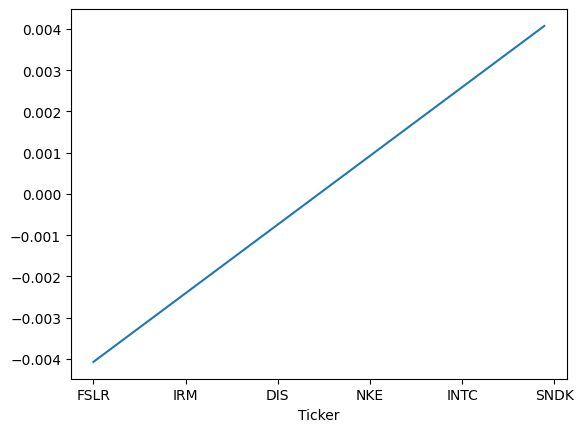

In [11]:
### Example portfolio
port.loc['20210330'].sort_values().plot()

<Axes: xlabel='Date'>

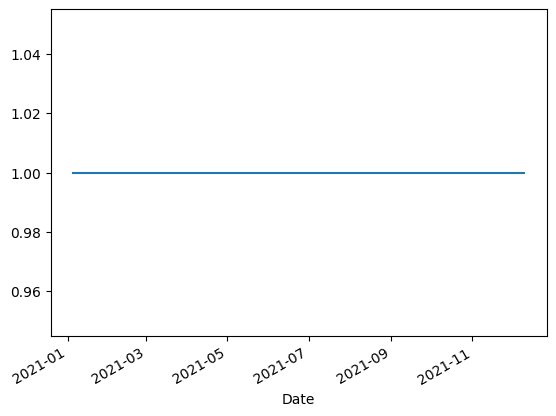

In [13]:
### Fully invested : abs value of port weights should sum to 1
port.abs().sum(1).plot()

<Axes: xlabel='Date'>

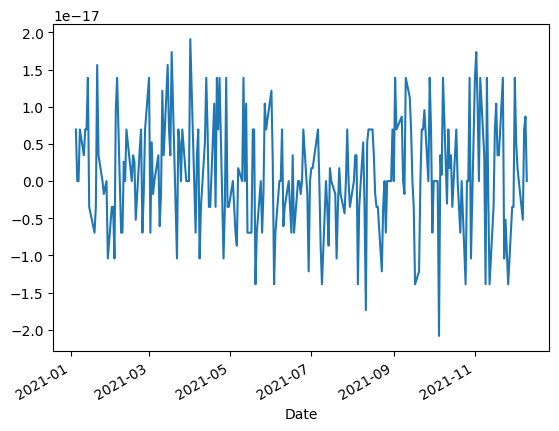

In [15]:
## Dollar neutrality : Port weights should sum to 0
port.sum(1).plot()

In [16]:
##compute strategy returns: implicitly assuming "market orders"
strat_ret = (port.shift()*ret).sum(1)

In [17]:
strat_ret

Date
2021-01-05    0.000000
2021-01-06   -0.005451
2021-01-07    0.002511
2021-01-08   -0.000225
2021-01-11    0.003622
                ...   
2021-12-06    0.003032
2021-12-07    0.006652
2021-12-08    0.000929
2021-12-09    0.002037
2021-12-10   -0.003399
Length: 237, dtype: float64

In [18]:
get_stats(strat_ret)

SR     1.457907
ret    0.095998
vol    0.065846
dtype: float64

<Axes: xlabel='Date'>

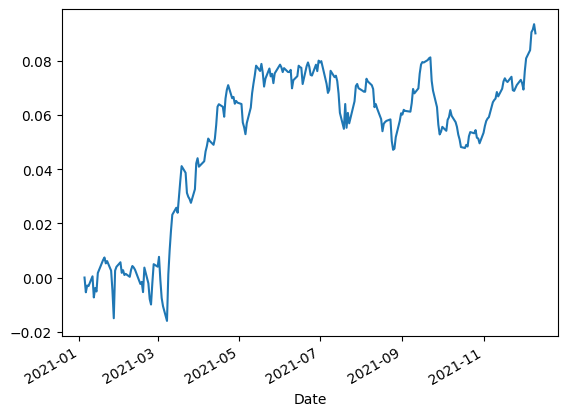

In [19]:
strat_ret.cumsum().plot()

In [20]:
## Create a simple XS 1 day reversal strategy using decile portfolios
negate = ret*-.1
pct = negate.rank(axis=1, pct=True)

long = (pct > 0.9)*1
long = long.divide(long.abs().sum(1), 0)*0.5

short = (pct < 0.1)*-1.0
short = short.divide(short.abs().sum(1),0)*0.5

port = short.add(long, fill_value = 0)


<Axes: xlabel='Ticker'>

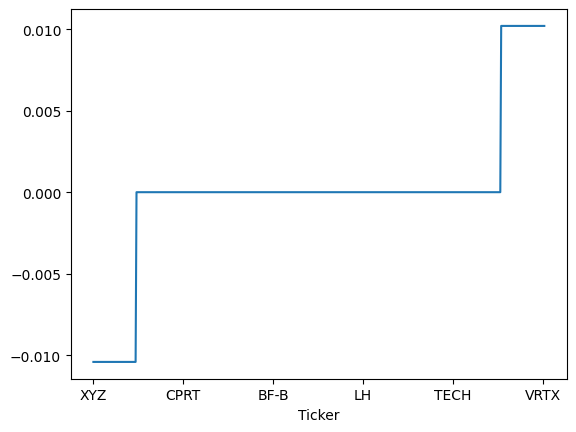

In [23]:
### example portfolio
port.loc['20210330'].sort_values().plot()

<Axes: xlabel='Date'>

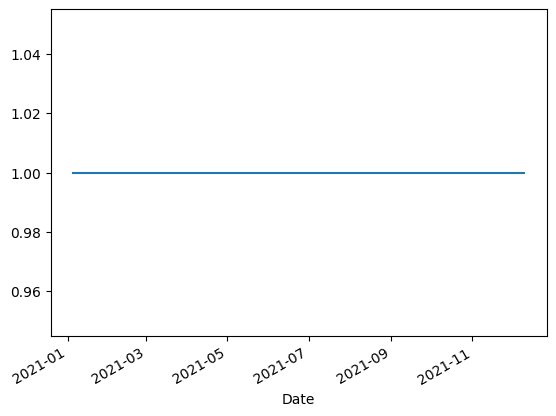

In [24]:
## fully invested : abs value of port weights should sum to 1
(port.abs()).sum(1).plot()

<Axes: xlabel='Date'>

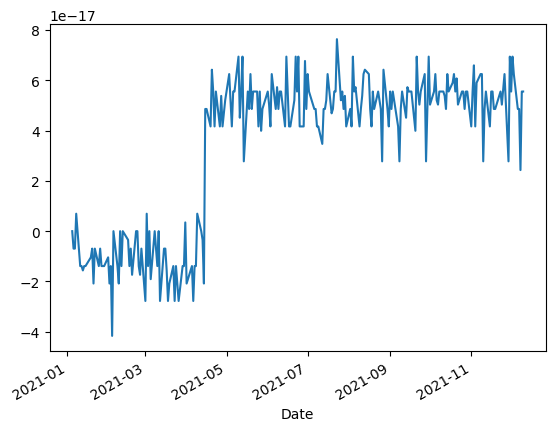

In [25]:
### Dollar neutrality: Port weights should sum to 0
port.sum(1).plot()

In [26]:
###Compute strategy returns: implicitly assuming "market orders"
strat_ret = (port.shift()*ret).sum(1)

In [27]:
get_stats(strat_ret)

SR     0.986503
ret    0.105549
vol    0.106993
dtype: float64

<Axes: xlabel='Date'>

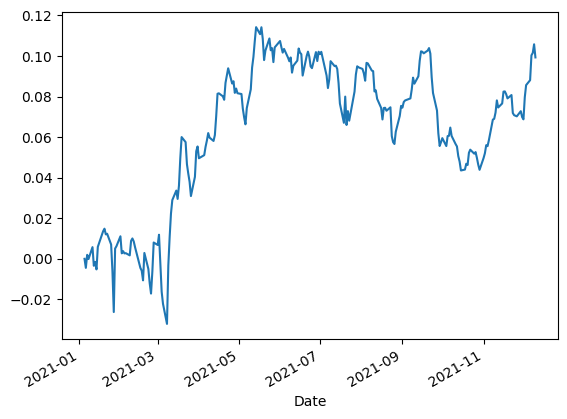

In [28]:
strat_ret.cumsum().plot()